## **Messwerte**

In [28]:
import  numpy as np

c_spezifisch_wasser = 4190 #Wärmekapazität von Wasser in J/Kg*K

c_spezifisch_eis = 2080 #Wärmekapazität von Eis in J/Kg*K


"""----------------------------------------------------------"""

m_Eis_1 = 0.1 #Masse des Eises in kg
m_Eis_1_Fehler = 0.001

m_wasser_1 = 0.1 #Masse des Wassers in kg
m_wasser_1_Fehler = 0.001


T_Fehler_1 = 0.1

T_Kalorimeter_vorher_1 = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8]) #Messung der Wassertemperatur vor Zugabe des Eises über 4 Minuten alle 30 Sekunden


T_Kalorimeter_zugabe_1 = np.array([1.7, 1.6, 1.5, 1.4, 1.3, 1.2]) #Messung der Temperatur nach Zugabe des Eises über eine Minute alle 10 Sekunden


T_Kalorimeter_zugabe_lanfristig_1 = np.array([1.3, 1.4, 1.5, 1.6, 1.7, 1.8]) #Messung der Temperatur nach der Zugabe und einer Minute für 3 Minuten alle 30 Sekunden

"""----------------------------------------------------------------------------------------------------------------------------------------------------------------"""

m_Eis_2 = 0.1 #Masse des Eises in kg
m_Eis_2_Fehler = 0.001

m_wasser_2 = 0.1 #Masse des Wassers in kg
m_wasser_2_Fehler = 0.001


T_Eis_Anfang_2 = 1 #Anfangstemperatur des Eises

T_Wasser_Anfang_2 = 2 #Anfangstemperatur des warmen Wassers


T_Fehler_2 = 0.1

T_Kalorimeter_vorher_2 = np.array([1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8]) #Messung der Wassertemperatur vor Zugabe des Eises über 4 Minuten alle 30 Sekunden


T_Kalorimeter_zugabe_2 = np.array([1.7, 1.6, 1.5, 1.4, 1.3, 1.2]) #Messung der Temperatur nach Zugabe des Eises über eine Minute alle 10 Sekunden


T_Kalorimeter_zugabe_lanfristig_2 = np.array([1.3, 1.4, 1.5, 1.6, 1.7, 1.8]) #Messung der Temperatur nach der Zugabe und einer Minute für 3 Minuten alle 30 Sekunden

## **Plots**

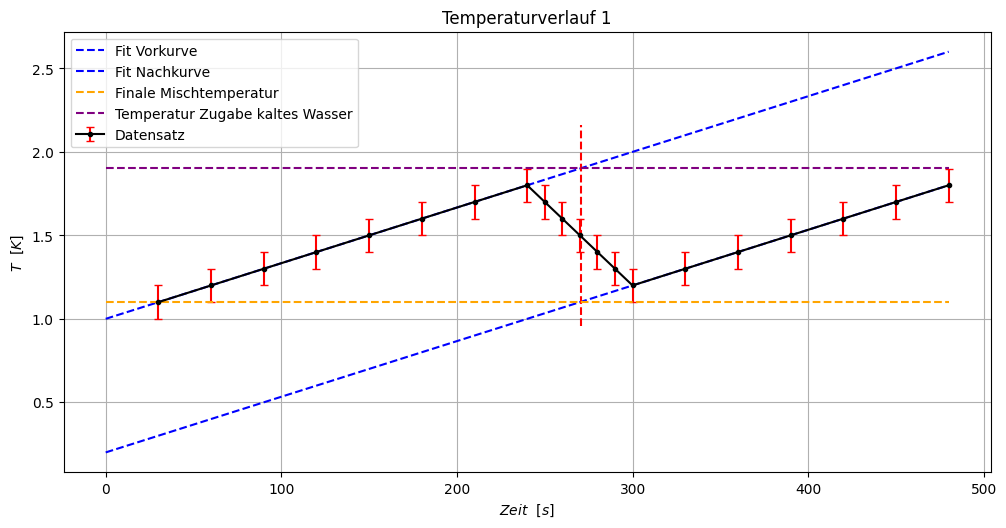

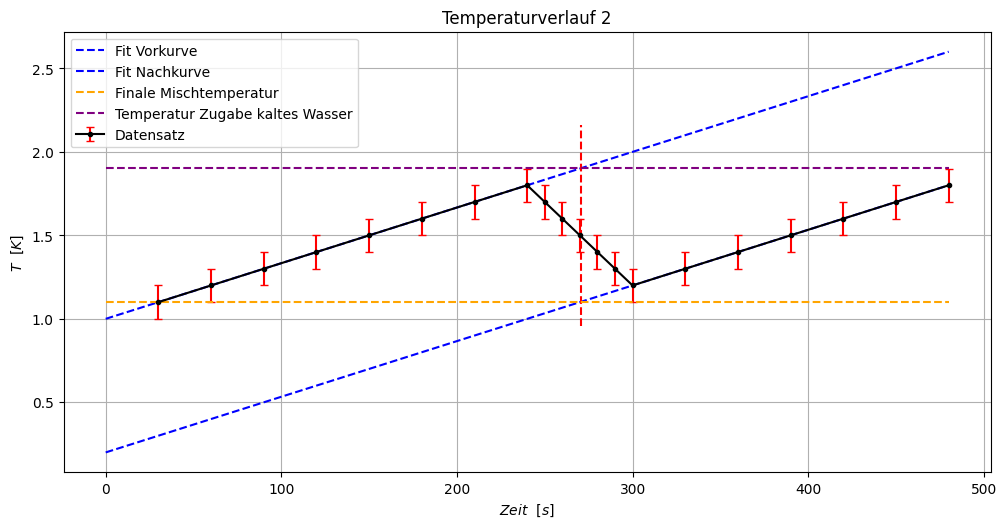

In [29]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import simpson
from scipy.optimize import fsolve
from scipy.integrate import quad

def f(x,k,a):
    return k*x +a

Zeiten = np.array([30, 60, 90, 120, 150, 180, 210, 240, 250, 260, 270, 280, 290, 300, 330, 360, 390, 420, 450, 480]) #Messzeiten in Sekunden

Zeiten_Vorkurve = Zeiten[0:8]
Zeiten_Nachkurve = Zeiten[14:21]
zeiten_hauptkurve = Zeiten[8:14]

t_Ende_Vorkurve = 240
t_Anfang_Nachkurve = 300

A_messung_1 = simpson(y=T_Kalorimeter_zugabe_1, x=zeiten_hauptkurve)
A_messung_2 = simpson(y=T_Kalorimeter_zugabe_2, x=zeiten_hauptkurve)

xwerte = np.linspace(0, 480, 1000)

def Dreiecksflaechen(xval, vork, nachk, A_messung):
    xval = xval[0] if isinstance(xval, (list, np.ndarray)) else xval

    if xval >= t_Anfang_Nachkurve or xval <= t_Ende_Vorkurve:
        return 100e6



    A1, _ = quad(vork, zeiten_hauptkurve[0], xval)
    A2, _ = quad(nachk, xval, zeiten_hauptkurve[-1])

    A_theorie = A1 + A2

    return A_theorie - A_messung

fig, ax1 = plt.subplots(1,1, figsize = (10,5))
fig.tight_layout()

"""----------------------------------------------------------------------------------------------------------------------------------------------------------"""

#Lineare Fits für Vor- und Nachkurve

coeficcients_1V, pcov = curve_fit(f, Zeiten_Vorkurve, T_Kalorimeter_vorher_1, sigma=T_Fehler_1, absolute_sigma=True)

def Vorkurve1(x):
    return coeficcients_1V[0]*x + coeficcients_1V[1]

ax1.plot(xwerte, Vorkurve1(xwerte), "b--", label = "Fit Vorkurve")


coeficcients_1N, pcov = curve_fit(f, Zeiten_Nachkurve, T_Kalorimeter_zugabe_lanfristig_1, sigma=T_Fehler_1, absolute_sigma=True)

def Nachkurve1(x):
    return coeficcients_1N[0]*x + coeficcients_1N[1]

ax1.plot(xwerte,Nachkurve1(xwerte), "b--", label = "Fit Nachkurve")

"""---------------------------------------------------------------------------------------------------------------------------------------------------------------"""
#Temperaturen mit dem Zwickelabgleich finden

h_1 = fsolve(Dreiecksflaechen, np.median(zeiten_hauptkurve) , args = (Vorkurve1, Nachkurve1, A_messung_1))[0]
ax1.vlines(h_1, ymin=np.min(T_Kalorimeter_zugabe_1)*0.8, ymax=np.max(T_Kalorimeter_vorher_1)*1.2, color = "red", linestyle = "dashed")

T_Zugabe_1 = Vorkurve1(h_1)
T_final_1 = Nachkurve1(h_1)

ax1.errorbar(Zeiten, np.concatenate((T_Kalorimeter_vorher_1, T_Kalorimeter_zugabe_1, T_Kalorimeter_zugabe_lanfristig_1) ,axis=0), yerr = T_Fehler_1, fmt = "o-", label = "Datensatz", color = "black", markersize  = 3 , capsize = 3, ecolor = "r")

ax1.hlines(T_final_1, xmin = 0, xmax = 480, color = "orange", linestyles= "dashed", label = "Finale Mischtemperatur")

ax1.hlines(T_Zugabe_1, xmin = 0, xmax = 480, color = "purple", linestyles= "dashed", label = "Temperatur Zugabe kaltes Wasser")

ax1.set_xlabel("$Zeit~~[s]$")
ax1.set_ylabel("$T~~[K]$")
ax1.grid(True)
ax1.set_title("Temperaturverlauf 1")
ax1.legend()


"""---------------------------------------------------------------------------------------------------------------------------------------------------------------"""
fig, ax2 = plt.subplots(1,1, figsize = (10,5))
fig.tight_layout()

#Lineare Fits für Vor- und Nachkurve

coeficcients_2V, pcov = curve_fit(f, Zeiten_Vorkurve, T_Kalorimeter_vorher_2, sigma=T_Fehler_2, absolute_sigma=True)

def Vorkurve2(x):
    return coeficcients_2V[0]*x + coeficcients_2V[1]

ax2.plot(xwerte, Vorkurve2(xwerte), "b--", label = "Fit Vorkurve")


coeficcients_2N, pcov = curve_fit(f, Zeiten_Nachkurve, T_Kalorimeter_zugabe_lanfristig_2, sigma=T_Fehler_2, absolute_sigma=True)

def Nachkurve2(x):
    return coeficcients_2N[0]*x + coeficcients_2N[1]

ax2.plot(xwerte,Nachkurve2(xwerte), "b--", label = "Fit Nachkurve")

"""---------------------------------------------------------------------------------------------------------------------------------------------------------------"""
#Temperaturen mit dem Zwickelabgleich finden

h_2 = fsolve(Dreiecksflaechen, np.median(zeiten_hauptkurve) , args = (Vorkurve2, Nachkurve2, A_messung_2))[0]
ax2.vlines(h_2, ymin=np.min(T_Kalorimeter_zugabe_2)*0.8, ymax=np.max(T_Kalorimeter_vorher_2)*1.2, color = "red", linestyle = "dashed")

T_Zugabe_2 = Vorkurve2(h_2)
T_final_2 = Nachkurve2(h_2)


ax2.errorbar(Zeiten, np.concatenate((T_Kalorimeter_vorher_2, T_Kalorimeter_zugabe_2, T_Kalorimeter_zugabe_lanfristig_2) ,axis=0), yerr = T_Fehler_2, fmt = "o-", label = "Datensatz", color = "black", markersize  = 3 , capsize = 3, ecolor = "r")

ax2.hlines(T_final_2, xmin = 0, xmax = 480, color = "orange", linestyles= "dashed", label = "Finale Mischtemperatur")

ax2.hlines(T_Zugabe_2, xmin = 0, xmax = 480, color = "purple", linestyles= "dashed", label = "Temperatur Zugabe kaltes Wasser")

ax2.set_xlabel("$Zeit~~[s]$")
ax2.set_ylabel("$T~~[K]$")
ax2.grid(True)
ax2.set_title("Temperaturverlauf 2")
ax2.legend()

## **Berechnung der Schmelzwärme**

In [30]:
from Skripte.Fehlerfortpflanzung import Gaußfehler
from IPython.display import display
import sympy

C_kalorimeter_1 = 1 #TODO
C_kalorimeter_2 = 1 #TODO

C_kalorimeter_1_Fehler = 1 #TODO
C_kalorimeter_2_Fehler = 1 #TODO

#TODO: Make sure all Temperatures are in Kelvin

L_1 = ((c_spezifisch_wasser*m_wasser_1 + C_kalorimeter_1)*(T_Zugabe_1 - T_final_1) / m_Eis_1) - c_spezifisch_wasser*(T_final_1 - 273.15)

cw, mw, Ck, Tz, Tf, mE = sympy.symbols("c_wasser, m_wasser, C_kalo, T_zugabe, T_final, m_Eis")

expr1 = ((cw*mw + Ck) * (Tz - Tf) / mE) - cw*(Tf - 273.15)
display(expr1)
Variablen = np.array([cw, mw, Ck, Tz, Tf, mE])
Mittelwerte_1 = np.array([c_spezifisch_wasser, m_wasser_1, C_kalorimeter_1, T_Zugabe_1, T_final_1, m_Eis_1])
Fehler_1 = np.array([0, m_wasser_1_Fehler, C_kalorimeter_1_Fehler, T_Fehler_1, T_Fehler_1, m_Eis_1_Fehler])

L_1_Fehler = Gaußfehler(expr1, Variablen, Mittelwerte_1, Fehler_1)

print(f"\nspezifische Schmelzwärme von Eis (1) : L = {L_1} +/- {L_1_Fehler} J/kg (Soll: 334000 J/kg)\n")

L_2 = ((c_spezifisch_wasser*m_wasser_2 + C_kalorimeter_2)*(T_Zugabe_2 - T_final_2) / m_Eis_2) - c_spezifisch_wasser*(T_final_2 - 273.15)

Mittelwerte_2 = np.array([c_spezifisch_wasser, m_wasser_2, C_kalorimeter_2, T_Zugabe_2, T_final_2, m_Eis_2])
Fehler_2 = np.array([0, m_wasser_2_Fehler, C_kalorimeter_2_Fehler, T_Fehler_2, T_Fehler_2, m_Eis_2_Fehler])

L_2_Fehler = Gaußfehler(expr1, Variablen, Mittelwerte_2, Fehler_2)

print(f"spezifische Schmelzwärme von Eis (2) : L = {L_2} +/- {L_2_Fehler} J/kg (Soll: 334000 J/kg)")


-c_wasser*(T_final - 273.15) + (C_kalo + c_wasser*m_wasser)*(-T_final + T_zugabe)/m_Eis


spezifische Schmelzwärme von Eis (1) : L = 1143237.861111111 +/- 939.487919241115 J/kg (Soll: 334000 J/kg)

spezifische Schmelzwärme von Eis (2) : L = 1143237.861111111 +/- 939.487919241115 J/kg (Soll: 334000 J/kg)
